# Klasifikasi Kesegaran Buah Menggunakan Metode GLCM dan Random Forest
## Percobaan 3 — Preprocessing: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening (5 Preprocessing)
### Nama Anggota
- Thoriq Abdillah Falian Kusuma : F1D02410098
- Jasmine Aulia Santoso : F1D02410010
- Ulul Asmi : F1D002410144
- Fatriya Annastha Putra : F1D02410046

## Import Library

Cell dibawah mengimpor seluruh library yang dibutuhkan sepanjang program.

Library `os` digunakan untuk melakukan navigasi sistem file, sehingga program dapat membaca folder dataset dan melakukan iterasi secara otomatis pada setiap subfolder kelas. `OpenCV (cv2)` digunakan untuk membaca citra dari media penyimpanan, melakukan konversi warna dari BGR ke grayscale, serta mengubah ukuran citra (resize) agar memiliki dimensi yang seragam. Untuk keperluan visualisasi, `Matplotlib (matplotlib.pyplot)` digunakan untuk menampilkan sampel citra, grafik distribusi data, dan confusion matrix.

Dalam pengolahan data numerik, `NumPy` digunakan untuk melakukan operasi pada array multidimensi yang berfungsi menyimpan data citra, label, serta hasil perhitungan fitur. `Pandas` digunakan untuk mengelola data hasil ekstraksi fitur dalam bentuk DataFrame serta menyimpan dan membaca data dalam format CSV. Pembagian dataset menjadi data latih dan data uji dilakukan menggunakan fungsi `train_test_split` dari library `scikit-learn`, sehingga proses pembagian data dapat dilakukan secara acak namun tetap dapat direproduksi.

Pada tahap ekstraksi fitur tekstur, digunakan fungsi `graycomatrix` dan `graycoprops` dari library `scikit-image` untuk membentuk Gray-Level Co-occurrence Matrix (GLCM) dan menghitung berbagai karakteristik tekstur seperti contrast, correlation, energy, dan homogeneity. Selain itu, fungsi `entrop` dari library `SciPy` digunakan untuk menghitung nilai entropi berdasarkan distribusi probabilitas pada matriks GLCM sebagai fitur tambahan yang merepresentasikan kompleksitas tekstur citra.

Tahap klasifikasi dilakukan menggunakan tiga algoritma pembelajaran mesin dari library scikit-learn, yaitu RandomForestClassifier sebagai metode klasifikasi berbasis ensemble pohon keputusan, SVC (Support Vector Classifier) sebagai implementasi algoritma Support Vector Machine (SVM) dengan kernel Radial Basis Function (RBF), serta KNeighborsClassifier yang menerapkan metode K-Nearest Neighbors (KNN). Evaluasi performa model dilakukan menggunakan berbagai metrik dari sklearn.metrics, meliputi accuracy, precision, recall, F1-score, classification report, dan confusion matrix. Selanjutnya, Seaborn digunakan untuk menghasilkan visualisasi statistik tingkat lanjut, khususnya dalam menampilkan heatmap correlation matrix yang digunakan untuk menganalisis hubungan antar fitur yang diekstraksi.

Perbedaan penggunaan dibanding Percobaan 1 & 2: Pada Percobaan 3, cv2.filter2D digunakan secara aktif untuk operasi Sharpening dengan kernel, sementara numpy dimanfaatkan secara lebih intensif untuk implementasi manual konvolusi Sobel (kernel Sx dan Sy) dan perhitungan magnitude gradien.

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Data Loading

Cell ini membaca seluruh gambar dari folder dataset dan melakukan resize seragam ke 250×250 piksel.

Yang dilakukan:


Fungsi resize_image(image, target_size=(250, 250)) didefinisikan sebagai wrapper modular untuk cv.resize()
Iterasi setiap subfolder dalam direktori Dataset/ masing-masing subfolder mewakili satu kelas
Setiap gambar dibaca, di-resize ke 250×250 piksel, dan dikonversi ke np.uint8
Gambar, label, dan nama file disimpan ke list masing-masing lalu dikonversi ke numpy array
Output: Total data: 828 dan Labels: ['Fresh_Apple' 'Moderately_Fresh_Apple' 'Rotten_Apple']


Ukuran resize 250×250 piksel konsisten dengan Percobaan 1 dan 2, memastikan dimensi seragam sebagai syarat pemrosesan batch dan komputasi GLCM yang efisien.

In [ ]:
def resize_image(image, target_size=(250, 250)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Dataset'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (250, 250))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 828
Labels: ['Fresh_Apple' 'Moderately_Fresh_Apple' 'Rotten_Apple']


## Data Understanding

Cell ini menampilkan distribusi jumlah gambar per kelas menggunakan bar chart.

Distribusi Dataset:

Fresh_Apple berjumlah 507 gambar dengan proporsi ±61.2%. 
Moderately_Fresh_Apple berjumlah 166 gambar dengan proporsi ±20.0%. 
Rotten_Apple berjumlah 155 gambar dengan proporsi ±18.7%.
Total berjumlah 828 gambar dengan proporsi 100%.

Dataset identik dengan Percobaan 1 dan 2. Distribusi tidak seimbang dengan Fresh_Apple mendominasi (~3× lebih banyak dari kelas lain) tetap menjadi karakteristik yang relevan dalam interpretasi hasil evaluasi model.

Karakteristik visual gambar:

Gambar diambil dengan kamera smartphone dalam kondisi pencahayaan dan background bervariasi
Apel segar: permukaan mulus, tekstur seragam, warna merah/hijau cerah
Apel cukup segar: mulai ada bercak kecil dan perubahan warna lokal
Apel busuk: permukaan tidak merata, bercak coklat/hitam signifikan, tekstur kasar

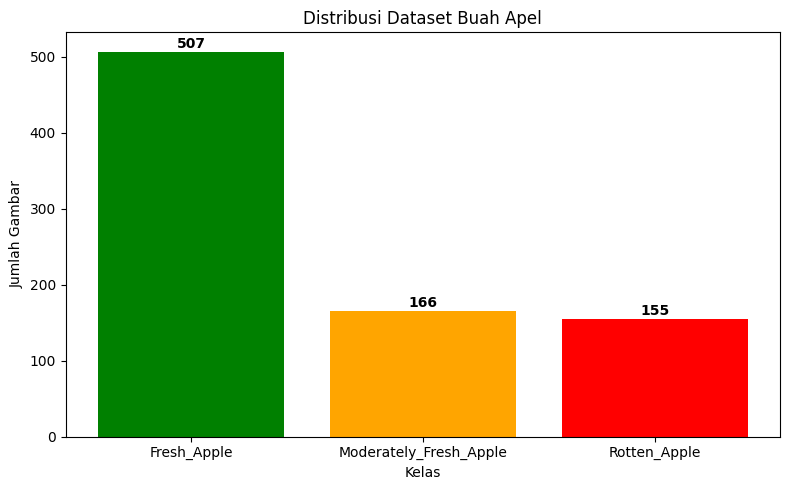

In [3]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['green', 'orange', 'red'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Buah Apel')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Sample Data

Cell ini menggunakan fungsi show_sample_images() untuk menampilkan contoh gambar original dari setiap kelas dalam format grid 3×3.

Yang dilakukan:

Fungsi menerima array gambar, label, nama kelas, judul, dan jumlah sampel (n=3)
Grid 3 baris × 3 kolom = 9 gambar total, gambar BGR dikonversi ke RGB sebelum ditampilkan
Dipanggil dengan judul 'Sample Data Original' untuk membedakan dari visualisasi di tahap preprocessing berikutnya


Tujuan: Memverifikasi data terbaca benar, warna natural, dan label sesuai konten. Fungsi ini bersifat reusable dan dipanggil kembali setelah setiap tahap preprocessing untuk memperlihatkan transformasi visual yang terjadi.

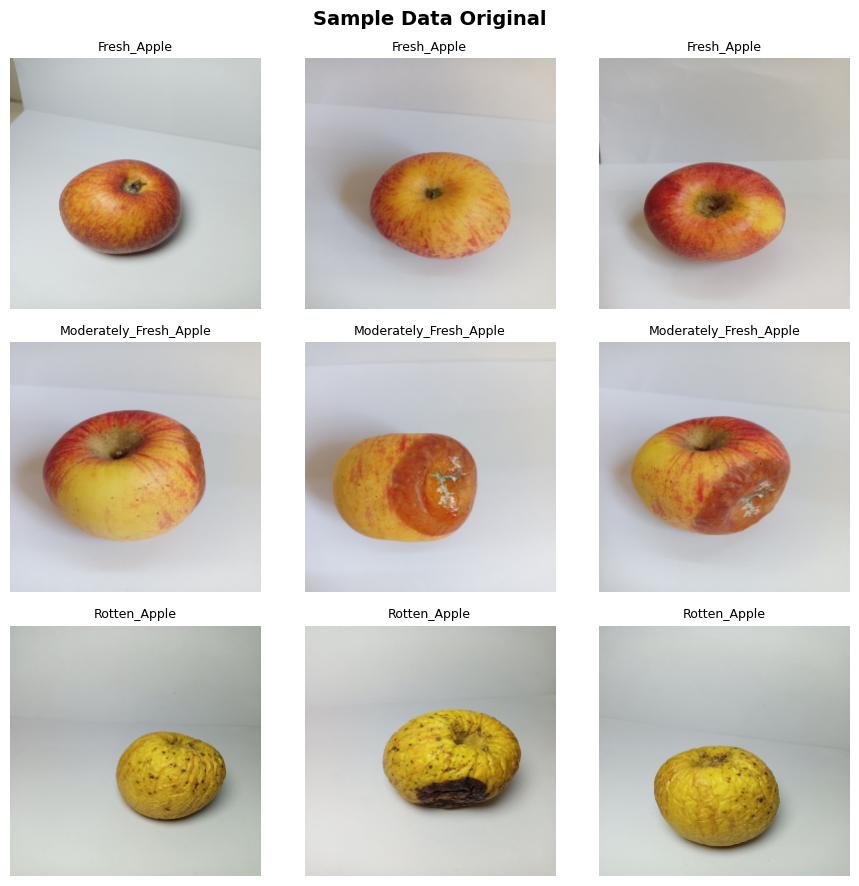

In [4]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Grayscale

Cell ini mengkonversi seluruh gambar dari BGR (3-channel) ke Grayscale (1-channel) menggunakan cv.cvtColor(img, cv.COLOR_BGR2GRAY).

Yang dilakukan:

Iterasi setiap gambar dalam data, konversi ke grayscale, simpan ke list img_grey
Hasil divisualisasikan dengan show_sample_images(img_grey, ..., 'Grayscale Images')


Grayscale dilakukan sebagai prasyarat wajib untuk seluruh preprocessing dan GLCM berikutnya, yaitu Sobel, Histogram Equalization, dan GLCM semuanya bekerja pada data intensitas tunggal (0–255). Formula pembobotan Y = 0.114B + 0.587G + 0.299R mempertahankan persepsi kecerahan yang akurat.

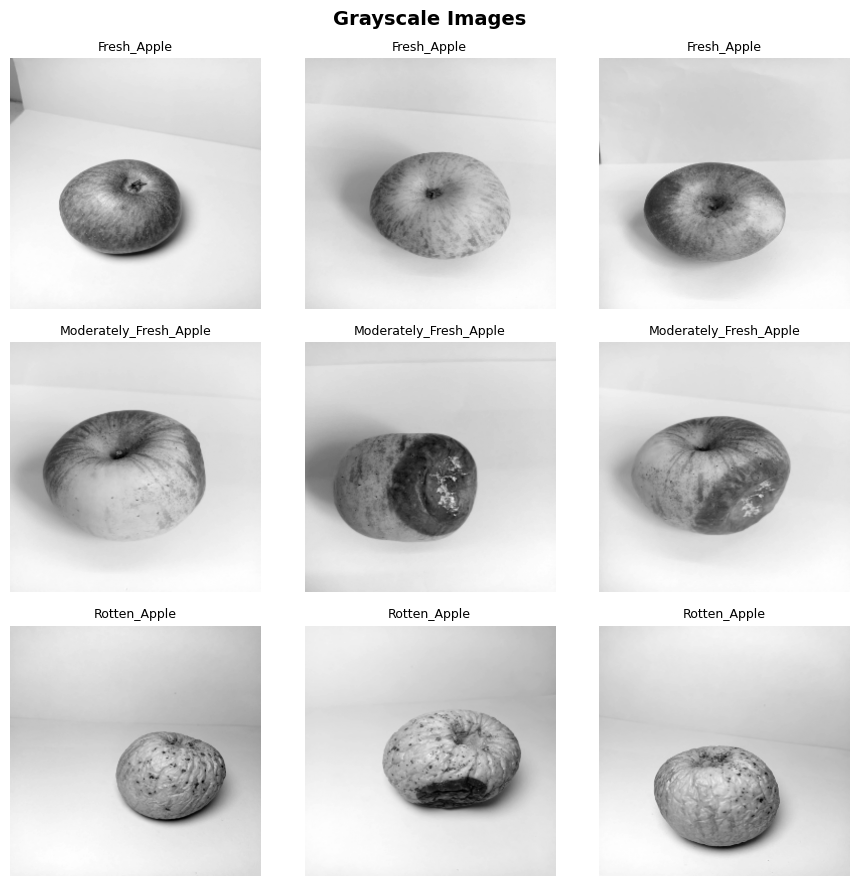

In [5]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

## Preprocessing 3: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening
Pada percobaan 3, digunakan 5 preprocessing:
1. **Resize** (sudah dilakukan saat data loading ke ukuran 250x250)
2. **Median Filter** — menghilangkan noise salt & pepper
3. **Histogram Equalization** — meningkatkan kontras gambar
4. **Sobel Edge Detection** — mendeteksi tepi/batas area busuk pada apel
5. **Sharpening** — mempertegas detail tekstur permukaan buah

### Step 1: Median Filter

Cell ini menerapkan Median Filter manual (kernel 3×3) pada gambar grayscale untuk menghilangkan noise.

Yang dilakukan:


Fungsi hitung_median() dan median_filter(image, kernel_size=3) diimplementasikan manual
Sliding window 3×3 digeser ke setiap piksel; nilai output = median dari 9 piksel dalam window
Gambar di-pad dengan np.pad(..., mode='reflect') agar tepi gambar tetap diproses
Hasil 828 gambar disimpan dalam img_median
Visualisasi ditampilkan dengan judul 'Hasil Median Filter'


Fungsi: Menghilangkan noise salt-and-pepper sambil mempertahankan tepi objek (edge-preserving), sehingga sinyal tepi pada tahap Sobel berikutnya tidak terkontaminasi noise.

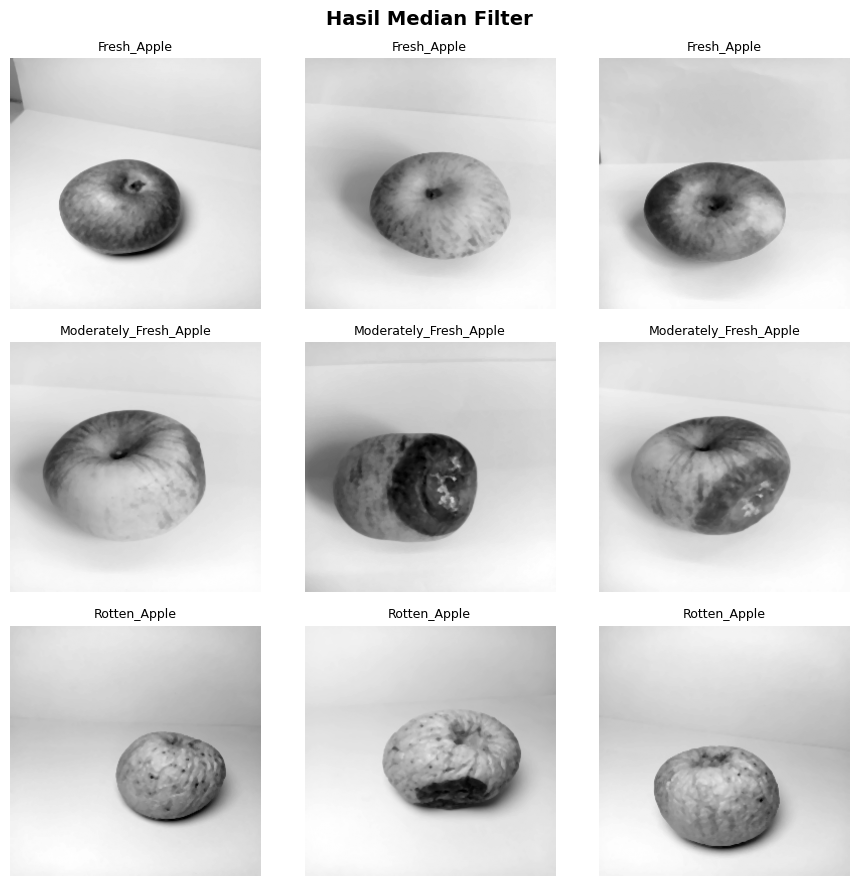

In [6]:
def hitung_median(image):
    return np.median(image)

def median_filter(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = hitung_median(window)
    return result.astype(np.uint8)

img_median = []
for img in img_grey:
    filtered = median_filter(img, kernel_size=3)
    img_median.append(filtered)
img_median = np.array(img_median)

show_sample_images(img_median, labels, class_names, 'Hasil Median Filter')

### Step 2: Histogram Equalization

Cell ini menerapkan Histogram Equalization manual pada hasil Median Filter.

Yang dilakukan:
Fungsi histogram_equalization(image) mengimplementasikan HE melalui langkah:


Hitung histogram intensitas (np.histogram, 256 bins)
Hitung CDF (Cumulative Distribution Function) dari histogram
Masking nilai CDF=0 untuk menghindari pembagian nol
Linear stretching: (cdf - min) * 255 / (max - min) → lookup table [0, 255]
Mapping setiap piksel melalui lookup table


Hasilnya disimpan dalam img_histeq dan divisualisasikan.

Fungsi: Meratakan distribusi intensitas ke rentang penuh [0–255] sehingga kontras lokal meningkat. Output HE menjadi input Sobel dengan kontras yang lebih tinggi menghasilkan gradien tepi yang lebih kuat dan lebih mudah dideteksi.

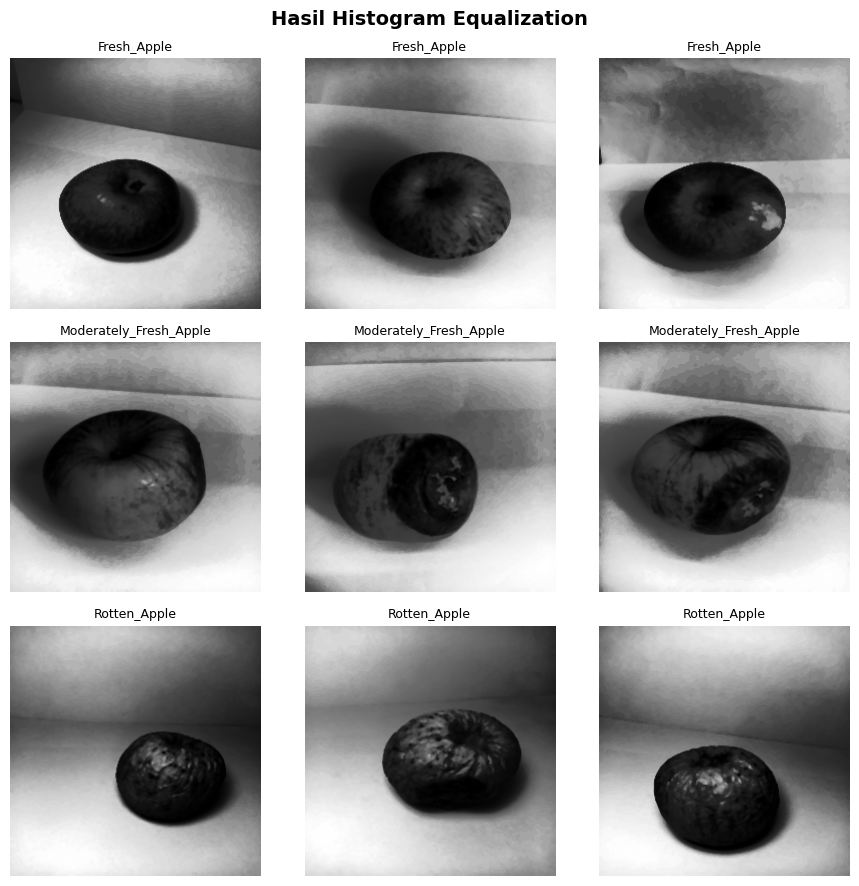

In [7]:
def histogram_equalization(image):
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf[image]

img_histeq = []
for img in img_median:
    equalized = histogram_equalization(img)
    img_histeq.append(equalized)
img_histeq = np.array(img_histeq)

show_sample_images(img_histeq, labels, class_names, 'Hasil Histogram Equalization')

### Step 3: Sobel Edge Detection

Cell ini menerapkan deteksi tepi Sobel manual menggunakan konvolusi kernel 3×3.

Yang dilakukan:

Fungsi convo_edge(image, kernel):

Implementasi konvolusi manual dengan padding reflektif
Sliding window mengalikan piksel dengan elemen kernel dan menjumlahkan hasilnya
Menghasilkan peta gradien dalam satu arah (horizontal atau vertikal)


Fungsi deteksi_tepi(image, Sx, Sy):

Gx = convo_edge(image, Sx) — gradien horizontal (tepi vertikal)
Gy = convo_edge(image, Sy) — gradien vertikal (tepi horizontal)
magnitude = √(Gx² + Gy²) — magnitude gradien total
np.clip(magnitude, 0, 255) — pembatasan ke rentang valid
Hasilnya disimpan dalam img_sobel dan divisualisasikan


Alasan menggunakan metode Sobel:

Apel busuk memiliki batas yang jelas antara area busuk (gelap, tidak merata) dan area sehat (terang, seragam), batas ini menghasilkan gradien intensitas tinggi yang tertangkap Sobel.
Gambar tepi Sobel menonjolkan pola tepi tekstur daripada intensitas absolut, memberikan representasi yang berbeda secara fundamental dari preprocessing sebelumnya.
Implementasi manual (tanpa cv2.Sobel) menunjukkan pemahaman algoritmik terhadap operasi konvolusi.


Dampak pada nilai fitur: Setelah Sobel, nilai Contrast meningkat drastis dibanding Percobaan 2 (rata-rata ~44.3 vs ~27.2) karena Sobel justru menghasilkan kontras tinggi di area tepi dan hampir nol di area datar. Ini mengubah karakteristik distribusi GLCM secara fundamental.

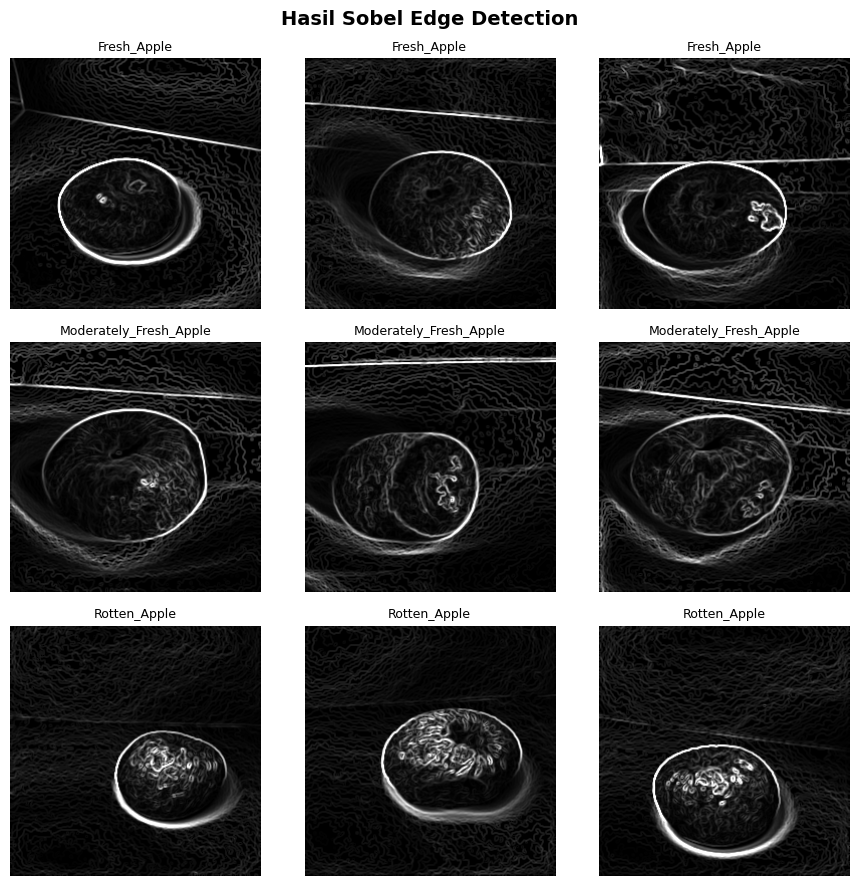

In [8]:
# Kernel Sobel
Sx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]])

Sy = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]])

def convo_edge(image, kernel):
    pad = kernel.shape[0] // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image, dtype=np.float64)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
            result[i, j] = np.sum(window * kernel)
    return result

def deteksi_tepi(image, Sx, Sy):
    Gx = convo_edge(image.astype(np.float64), Sx)
    Gy = convo_edge(image.astype(np.float64), Sy)
    magnitude = np.sqrt(Gx**2 + Gy**2)
    magnitude = np.clip(magnitude, 0, 255)
    return magnitude.astype(np.uint8)

img_sobel = []
for img in img_histeq:
    sobel = deteksi_tepi(img, Sx, Sy)
    img_sobel.append(sobel)
img_sobel = np.array(img_sobel)

show_sample_images(img_sobel, labels, class_names, 'Hasil Sobel Edge Detection')

### Step 4: Sharpening

Cell ini menerapkan filter sharpening pada hasil Sobel untuk mempertegas detail tekstur.

Yang dilakukan:

Fungsi sharpen_image(image) menggunakan kernel sharpening:

cv.filter2D(image, -1, kernel) adalah konvolusi dengan kernel sharpening menggunakan OpenCV
np.clip(sharpened, 0, 255).astype(np.uint8) adalah clipping agar nilai tetap valid
Diterapkan ke seluruh img_sobel (828 gambar) sehingga hasilnya disimpan dalam dataPreprocessed
Visualisasi akhir pipeline ditampilkan dengan judul 'Hasil Preprocessing 3: Median + HistEq + Sobel + Sharpening'


Alasan menggunakan kernel sharpening:
Kernel di atas adalah Laplacian-based sharpening jumlah elemen = 0 (-8/9 + 8/9 = 0), artinya area seragam tidak berubah, namun area dengan perbedaan intensitas (tepi) menjadi lebih menonjol. Ini mempertegas batas-batas yang sudah dideteksi oleh Sobel, menghasilkan representasi tekstur yang lebih tajam dan kontras untuk input GLCM.

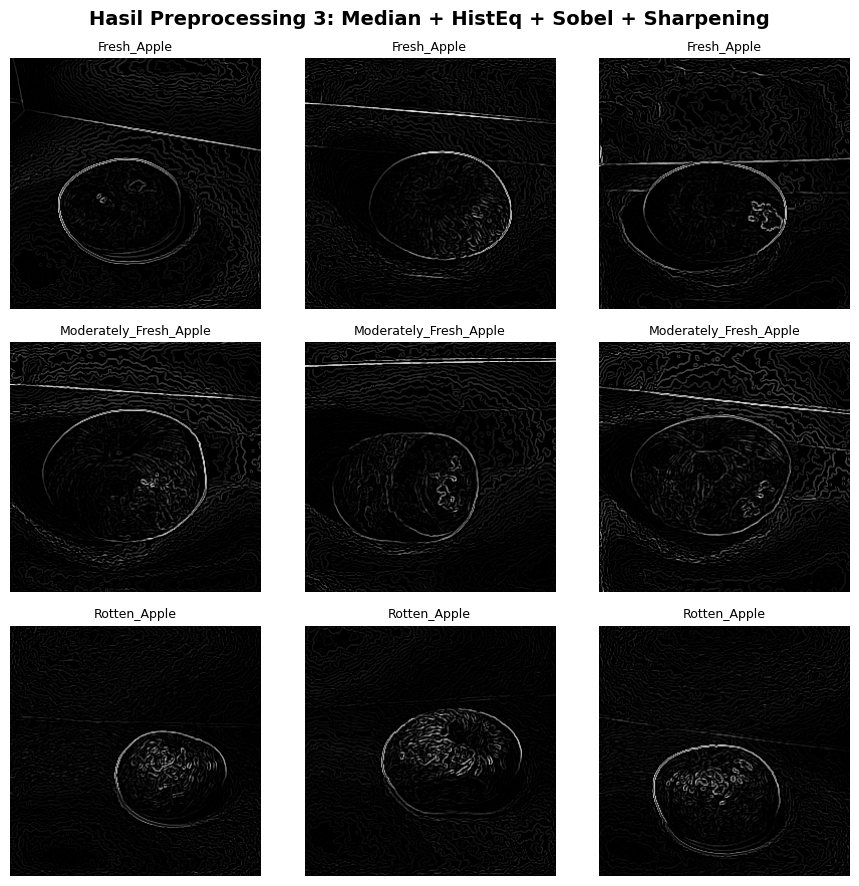

In [9]:
def sharpen_image(image):
    kernel = np.array([[-1/9, -1/9, -1/9],
                       [-1/9,  8/9, -1/9],
                       [-1/9, -1/9, -1/9]])
    sharpened = cv.filter2D(image, -1, kernel)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

dataPreprocessed = []
for img in img_sobel:
    sharpened = sharpen_image(img)
    dataPreprocessed.append(sharpened)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Hasil Preprocessing 3: Median + HistEq + Sobel + Sharpening')

## Feature Extraction — GLCM
Mengekstrak 7 fitur tekstur dari GLCM pada 4 sudut (0°, 45°, 90°, 135°):
- Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, Correlation

Total: 7 fitur × 4 sudut = **28 fitur per gambar**

Cell ini mendefinisikan fungsi-fungsi untuk menghitung GLCM dan mengekstrak 7 fitur tekstur dari 4 sudut arah (0°, 45°, 90°, 135°).

Fungsi glcm(image, derajat):
Menghitung matriks GLCM menggunakan graycomatrix() dengan parameter:


distances=[1] — jarak antar piksel = 1 piksel
angles disesuaikan per sudut input
levels=256, symmetric=True, normed=True


7 Fitur yang Diekstrak:

1. Contrast

Dihitung menggunakan fungsi graycoprops(m, 'contrast').
Mengukur tingkat perbedaan intensitas antara piksel-piksel yang bertetangga.
Nilai contrast yang tinggi menunjukkan adanya variasi intensitas yang besar, sehingga tekstur cenderung lebih kasar dan tidak seragam.
Sebaliknya, nilai yang rendah menunjukkan tekstur yang lebih halus.

2. Dissimilarity

Dihitung menggunakan fungsi graycoprops(m, 'dissimilarity').
Mengukur variasi lokal tekstur berdasarkan perbedaan tingkat keabuan antar piksel yang berdekatan.
Fitur ini memiliki konsep yang mirip dengan contrast, tetapi pertumbuhan nilainya bersifat linear terhadap perbedaan intensitas.
Nilai yang tinggi menunjukkan tekstur yang lebih beragam dan tidak homogen.

3. Homogeneity

Dihitung menggunakan fungsi graycoprops(m, 'homogeneity').
Mengukur kedekatan distribusi nilai pada matriks GLCM terhadap diagonal utama.
Nilai homogeneity yang tinggi menunjukkan bahwa pasangan piksel memiliki tingkat keabuan yang mirip.
Tekstur yang halus dan seragam umumnya menghasilkan nilai homogeneity yang tinggi.

4. Angular Second Moment (ASM)

Dihitung menggunakan fungsi graycoprops(m, 'ASM').
Mengukur tingkat keseragaman atau keteraturan distribusi tekstur dalam citra.
Nilai ASM yang tinggi menunjukkan bahwa tekstur memiliki pola yang sangat seragam dan teratur.
Semakin terkonsentrasi distribusi nilai dalam matriks GLCM, semakin tinggi nilai ASM yang diperoleh.

5. Energy

Dihitung menggunakan fungsi graycoprops(m, 'energy').
Merupakan akar kuadrat dari nilai ASM.
Menggambarkan tingkat keseragaman tekstur dengan interpretasi yang serupa dengan ASM.
Nilai energy yang tinggi menunjukkan tekstur yang lebih homogen dan teratur.

6. Correlation

Dihitung menggunakan fungsi graycoprops(m, 'correlation').
Mengukur tingkat ketergantungan atau hubungan linear antara intensitas piksel yang bertetangga.
Nilai correlation yang tinggi menunjukkan adanya pola hubungan yang kuat dan konsisten pada tekstur citra.
Fitur ini membantu menggambarkan struktur tekstur yang terbentuk dalam arah tertentu.

7. Entropy

Dihitung menggunakan fungsi entropy(matriks.ravel()).
Mengukur tingkat kerumitan, ketidakteraturan, atau keacakan tekstur pada citra.
Nilai entropy yang tinggi menunjukkan tekstur yang lebih kompleks dan tidak teratur.
Sebaliknya, nilai entropy yang rendah menunjukkan tekstur yang lebih sederhana dan seragam.


Total fitur: 7 fitur × 4 sudut = 28 fitur per gambar

In [10]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Hitung GLCM untuk Setiap Gambar pada 4 Sudut

Cell ini menjalankan komputasi GLCM untuk seluruh 828 gambar pada keempat sudut.

Yang dilakukan:


Inisialisasi 4 list: Derajat0, Derajat45, Derajat90, Derajat135
Loop 828 iterasi setiap iterasi memanggil glcm() empat kali
Input adalah gambar dari dataPreprocessed (hasil pipeline 5-tahap lengkap)
Output konfirmasi: 'GLCM computed for 828 images'


Perbedaan kunci dibanding Percobaan 1 & 2: Gambar input ke GLCM kali ini adalah gambar tepi Sobel yang dipertegas, bukan gambar grayscale atau gambar dengan kontras ditingkatkan. Matriks GLCM yang dihasilkan memiliki karakteristik sangat berbeda: banyak entri bernilai 0 (area datar/hitam) dan entri besar terkonsentrasi pada pasangan intensitas rendah-rendah, menghasilkan nilai ASM dan Energy yang jauh lebih tinggi dibanding percobaan sebelumnya.

In [11]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 828 images


Ekstraksi 7 Fitur GLCM

Cell ini mengekstrak nilai numerik dari setiap matriks GLCM yang sudah dihitung.

Yang dilakukan:


Inisialisasi 28 list kosong (7 fitur × 4 sudut)
Loop 828 iterasi: memanggil 7 fungsi fitur pada 4 matriks GLCM per gambar
Total: 828 × 7 × 4 = 23.184 perhitungan fitur
Output: 'Feature extraction completed!'


Fungsi: Mengubah representasi matriks GLCM menjadi vektor fitur numerik (28 nilai per gambar) yang siap digunakan oleh algoritma machine learning.

In [12]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


### Simpan Hasil Ekstraksi ke CSV

Cell ini menyusun semua fitur ke dalam DataFrame dan menyimpannya ke hasil_ekstraksi_percobaan3.csv.

Yang dilakukan:


Dictionary dataTable dengan 30 kolom: Filename, Label, dan 28 kolom fitur
DataFrame disimpan ke CSV, kemudian dibaca kembali ke hasilEkstrak untuk verifikasi

Perbandingan nilai fitur antar percobaan (Contrast0 dan Correlation0):

Untuk menganalisis pengaruh tahapan preprocessing terhadap karakteristik fitur tekstur yang dihasilkan, dilakukan perbandingan beberapa statistik penting pada fitur Contrast, Correlation, dan ASM (Angular Second Moment). Hasil perbandingan menunjukkan adanya perubahan yang cukup signifikan antar percobaan.

1. Contrast (Rata-rata)

Percobaan 1: sekitar 10,9
Percobaan 2: sekitar 27,2
Percobaan 3: sekitar 44,3

Nilai rata-rata contrast terus meningkat dari Percobaan 1 hingga Percobaan 3. Hal ini menunjukkan bahwa perbedaan intensitas antar piksel menjadi semakin besar sehingga tekstur yang dihasilkan tampak lebih kontras dan lebih menonjol.

2. Contrast (Standar Deviasi)

Percobaan 1: sekitar 4,5
Percobaan 2: sekitar 11,6
Percobaan 3: sekitar 13,1

Peningkatan standar deviasi menunjukkan bahwa variasi nilai contrast antar citra semakin besar. Dengan kata lain, penyebaran data menjadi lebih luas dan karakteristik tekstur antar gambar semakin beragam.

3. Contrast (Nilai Maksimum)

Percobaan 1: sekitar 21,4
Percobaan 2: sekitar 100,3
Percobaan 3: sekitar 167,8

Nilai maksimum contrast mengalami peningkatan yang sangat signifikan. Hasil ini menunjukkan bahwa terdapat citra-citra dengan perbedaan intensitas yang jauh lebih tinggi pada Percobaan 3 dibandingkan dua percobaan sebelumnya.

4. Correlation (Rata-rata)

Percobaan 1: sekitar 0,998
Percobaan 2: sekitar 0,998
Percobaan 3: sekitar 0,623

Pada Percobaan 1 dan Percobaan 2, nilai correlation hampir sempurna, yang menunjukkan hubungan linear yang sangat kuat antara piksel yang bertetangga. Namun, pada Percobaan 3 nilai correlation turun drastis menjadi sekitar 0,623. Penurunan ini menunjukkan bahwa keteraturan hubungan antar piksel menjadi lebih rendah dan pola tekstur menjadi lebih kompleks.

5. Correlation (Standar Deviasi)

Percobaan 1: sekitar 0,001
Percobaan 2: sekitar 0,001
Percobaan 3: sekitar 0,072

Standar deviasi correlation pada Percobaan 3 meningkat secara signifikan dibandingkan dua percobaan sebelumnya. Hal ini menunjukkan bahwa hubungan antar piksel menjadi lebih bervariasi dan tidak lagi seragam di seluruh dataset.

6. ASM (Rata-rata)

Percobaan 1: sekitar 0,012
Percobaan 2: sekitar 0,012
Percobaan 3: sekitar 0,186

Nilai rata-rata ASM meningkat sangat besar pada Percobaan 3. Karena ASM mengukur tingkat keseragaman tekstur, peningkatan ini menunjukkan bahwa distribusi nilai pada matriks GLCM menjadi lebih terkonsentrasi dan teratur dibandingkan dua percobaan sebelumnya.

Alasan nilai fitur Percobaan 3 sangat berbeda:


Contrast meningkat drastis (~44.3, max ~167.8): Sobel Edge Detection menghasilkan gambar dengan piksel bernilai tinggi di area tepi dan mendekati 0 di area datar. Kontrast antara area tepi (intensitas tinggi) dan area datar (intensitas ~0) jauh lebih ekstrem dibanding gambar grayscale biasa. Sharpening mempertegas perbedaan ini lebih jauh.
Correlation turun drastis (~0.623 vs ~0.998): Ini adalah perubahan paling signifikan. Pada gambar grayscale alami, piksel bertetangga sangat berkorelasi (bervariasi halus). Namun pada gambar Sobel, piksel tepi memiliki nilai tinggi yang dikelilingi piksel bernilai ~0 — transisi abrupt ini merusak korelasi spasial, sehingga nilai Correlation turun jauh.
ASM meningkat drastis (~0.186 vs ~0.012): Pada gambar Sobel, mayoritas piksel bernilai ~0 (area datar/background). Ini menciptakan matriks GLCM yang sangat "terpusat" pada entri (0,0), menghasilkan distribusi yang sangat tidak merata dengan satu entri dominan — persis kondisi yang menghasilkan ASM tinggi.

In [13]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG20260206230128.jpg,Fresh_Apple,47.472064,91.250157,88.157992,97.824438,0.565426,0.457079,0.500219,0.462328,...,0.155843,0.130995,0.435676,0.358688,0.394770,0.361933,0.641466,0.312877,0.334318,0.263372
1,IMG20260211121459.jpg,Fresh_Apple,30.125189,76.086450,73.973285,87.951033,0.549944,0.443904,0.480457,0.428823,...,0.129313,0.103570,0.405781,0.331909,0.359600,0.321823,0.733832,0.329968,0.347231,0.225486
2,IMG20260210121908.jpg,Fresh_Apple,53.753092,99.384300,86.918233,101.963484,0.565955,0.471881,0.520688,0.470374,...,0.171248,0.140277,0.444104,0.375755,0.413822,0.374535,0.632791,0.323210,0.407055,0.305647
3,IMG20260205230128.jpg,Fresh_Apple,62.447936,110.173449,106.322795,124.683634,0.549976,0.435599,0.460330,0.423447,...,0.136566,0.114347,0.430203,0.347791,0.369549,0.338153,0.583876,0.268021,0.291781,0.171617
4,IMG20260210121652.jpg,Fresh_Apple,46.339422,93.330527,84.799149,99.148917,0.577261,0.475768,0.526263,0.489499,...,0.183019,0.157825,0.463130,0.388563,0.427807,0.397272,0.671911,0.341244,0.399910,0.300176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,IMG20260409231757.jpg,Rotten_Apple,45.863373,72.641796,56.508032,74.592861,0.558263,0.419422,0.447681,0.407281,...,0.109342,0.091668,0.399705,0.309332,0.330669,0.302768,0.537670,0.270073,0.430344,0.250468
824,IMG20260409231817.jpg,Rotten_Apple,37.833542,54.854293,41.515871,56.882905,0.554662,0.425441,0.449560,0.404681,...,0.109000,0.089222,0.392033,0.310580,0.330151,0.298700,0.508732,0.289976,0.461007,0.263718
825,IMG20260409231714.jpg,Rotten_Apple,56.350843,89.028661,69.923373,85.701263,0.569973,0.414971,0.460659,0.439484,...,0.110908,0.100186,0.398748,0.301587,0.333028,0.316521,0.537186,0.271326,0.425729,0.298560
826,IMG20260409231801.jpg,Rotten_Apple,41.753558,68.893018,57.798056,76.681892,0.536409,0.424538,0.449122,0.388314,...,0.110850,0.084948,0.386825,0.314254,0.332942,0.291458,0.585114,0.317644,0.425780,0.240498


## Feature Selection

Cell ini menerapkan seleksi fitur berbasis Correlation Matrix dengan threshold 0.95.

Yang dilakukan:


Matriks korelasi Pearson dihitung dari 28 fitur
Threshold = 0.95 — fitur dengan korelasi ≥ 0.95 satu sama lain dieliminasi (yang duplikat di-drop)
Fitur terpilih tersimpan dalam select, data tereduksi dalam x_new
Heatmap correlation matrix divisualisasikan dengan seaborn


Output Seleksi:


Fitur sebelum seleksi: 26 fitur
Fitur setelah seleksi: 15 fitur


Fitur terpilih (15 fitur):
Contrast0, Contrast45, Homogeneity0, Homogeneity45, Homogeneity90, Homogeneity135, Dissimilarity0, Dissimilarity45, Entropy0, ASM0, ASM45, Correlation0, Correlation45, Correlation90, Correlation135

Analisis Hasil Correlation Matrix (dari gambar heatmap Percobaan 3):

Heatmap Percobaan 3 memperlihatkan pola korelasi yang berbeda secara signifikan dari Percobaan 1 dan 2, mencerminkan transformasi fundamental yang dilakukan Sobel:


Blok Contrast (kiri atas): Contrast0–45 berkorelasi tinggi (0.74), namun Contrast tidak lagi berkorelasi sangat tinggi dengan semua sudut seperti di P1/P2. Ini karena Sobel menghasilkan pola tepi yang lebih bervariasi per sudut.
Blok Homogeneity (kiri tengah): Homogeneity45–135 berkorelasi sangat tinggi antar sesama (0.77–0.92), beberapa dieliminasi. Homogeneity0 memiliki korelasi lebih rendah dengan sudut lain karena arah tepi horizontal memiliki karakteristik berbeda.
Contrast vs Homogeneity: Korelasi negatif lebih kuat (−0.42 hingga −0.65) — kontras tepi tinggi berarti homogenitas rendah, hubungan ini lebih tegas pasca-Sobel.
Blok Dissimilarity: Berkorelasi tinggi antar sesama (0.84–0.88) dan juga dengan Contrast (0.83–0.85), keduanya sama-sama mengukur "kekasaran" dan menghasilkan nilai tinggi pada area tepi Sobel.
ASM0 vs ASM45: Berkorelasi sangat tinggi (0.94), keduanya sama-sama dipengaruhi dominasi piksel bernilai 0 pasca-Sobel, meskipun akhirnya keduanya dipertahankan karena tepat di bawah threshold 0.95.
Blok Correlation (kanan bawah): Korelasi antar Correlation0–135 hanya sekitar 0.36–0.56 — jauh lebih rendah dari P1/P2 yang mendekati 1.0. Ini berarti nilai korelasi GLCM pada setiap sudut memberikan informasi yang berbeda-beda setelah Sobel, sehingga semua 4 sudut Correlation dipertahankan.
Entropy berkorelasi negatif dengan ASM (−0.13 hingga −0.34), lebih lemah dari P1/P2 karena distribusi GLCM pasca-Sobel sangat dominan di satu area, mengurangi variasi entropi.


Secara keseluruhan, heatmap P3 menunjukkan struktur korelasi yang lebih heterogen dibanding P1/P2 — mencerminkan bahwa Sobel + Sharpening menghasilkan representasi fitur yang lebih beragam dan informatif per sudut.

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 15
Fitur terpilih: ['Contrast0', 'Contrast45', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'Dissimilarity0', 'Dissimilarity45', 'Entropy0', 'ASM0', 'ASM45', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


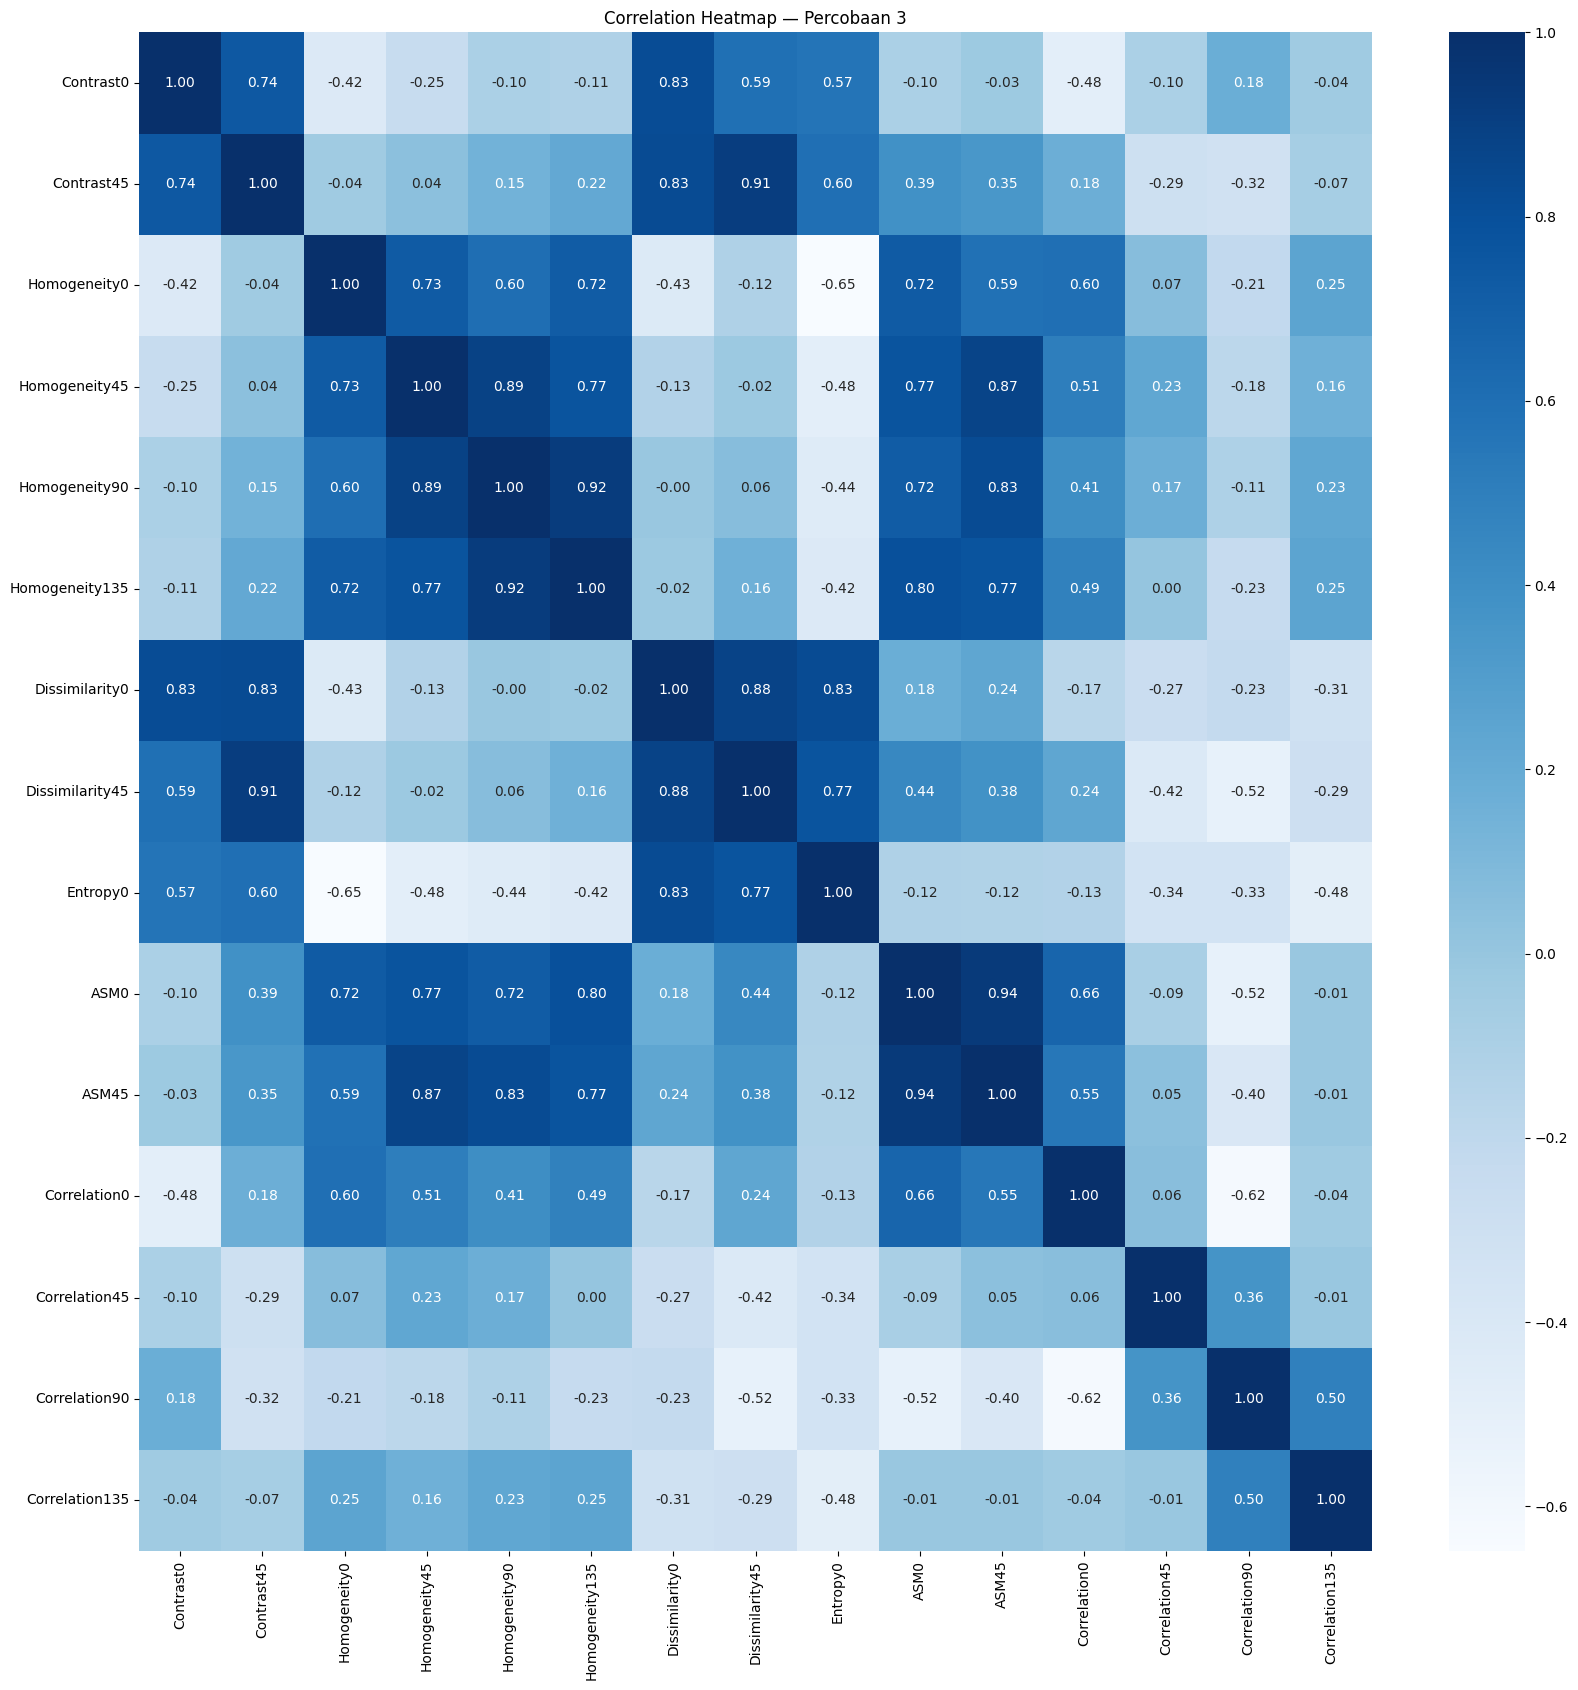

In [14]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 3')
plt.tight_layout()
plt.show()

## Splitting Data

Cell ini membagi dataset menjadi data training (80%) dan data testing (20%).

Yang dilakukan:

pythonX_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)

random_state=42 identik dengan Percobaan 1 dan 2 memastikan pembagian data yang sama persis sehingga perbandingan antar percobaan hanya mencerminkan pengaruh preprocessing, bukan perbedaan komposisi data.

Perbandingan Dimensi Fitur Antar Percobaan

Untuk mengetahui pengaruh setiap tahapan preprocessing terhadap jumlah fitur yang digunakan dalam proses klasifikasi, dilakukan perbandingan jumlah fitur terpilih dan dimensi data training pada ketiga percobaan. Hasil yang diperoleh menunjukkan adanya peningkatan jumlah fitur yang dipertahankan seiring bertambahnya tahapan preprocessing.

1. Percobaan 1

Preprocessing: Resize + Median Filter
Jumlah fitur terpilih: 12 fitur
Dimensi data training: (662, 12)

Pada percobaan pertama, citra hanya melalui proses resize dan median filter sebelum dilakukan ekstraksi fitur. Setelah proses seleksi fitur, diperoleh 12 fitur yang dianggap paling relevan untuk membedakan kelas apel. Oleh karena itu, data training memiliki dimensi 662 baris data dan 12 kolom fitur.

2. Percobaan 2

Preprocessing: Resize + Median Filter + Histogram Equalization
Jumlah fitur terpilih: 14 fitur
Dimensi data training: (662, 14)

Penambahan proses histogram equalization meningkatkan kontras citra sehingga lebih banyak karakteristik tekstur yang dapat ditangkap oleh fitur GLCM. Hasil seleksi fitur menunjukkan bahwa 14 fitur dipertahankan untuk proses klasifikasi. Akibatnya, dimensi data training meningkat menjadi 662 baris data dan 14 kolom fitur.

3. Percobaan 3

Preprocessing: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening
Jumlah fitur terpilih: 15 fitur
Dimensi data training: (662, 15)

Pada percobaan ketiga, ditambahkan proses deteksi tepi menggunakan Sobel dan penajaman citra (sharpening). Tahapan ini menghasilkan informasi tekstur yang lebih kaya sehingga jumlah fitur yang lolos seleksi meningkat menjadi 15 fitur. Dengan demikian, data training memiliki dimensi sebesar 662 baris data dan 15 kolom fitur.

Kesimpulan

Hasil perbandingan menunjukkan bahwa semakin kompleks tahapan preprocessing yang diterapkan, semakin banyak fitur yang dianggap relevan dan dipertahankan dalam proses klasifikasi. Jumlah fitur terpilih meningkat dari 12 fitur pada Percobaan 1, menjadi 14 fitur pada Percobaan 2, dan 15 fitur pada Percobaan 3. Konsekuensinya, dimensi data training juga bertambah dari (662, 12) menjadi (662, 14) dan akhirnya (662, 15).

Peningkatan jumlah fitur ini menunjukkan bahwa penambahan preprocessing seperti Histogram Equalization, Sobel, dan Sharpening mampu menghasilkan variasi informasi tekstur yang lebih banyak. Namun, bertambahnya jumlah fitur tidak selalu menjamin peningkatan akurasi klasifikasi, karena kualitas dan relevansi fitur terhadap proses pemisahan kelas tetap menjadi faktor yang lebih penting dibandingkan jumlah fitur saja.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (662, 15)
Testing set: (166, 15)


## Feature Normalization

Cell ini menerapkan Z-score normalization menggunakan statistik dari data training.

Yang dilakukan:

pythonX_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Setelah pipeline Sobel + Sharpening, skala fitur menjadi sangat ekstrem — Contrast memiliki rentang 17–167 sementara Correlation berkisar 0.36–0.80. Normalisasi Z-score menjadi kritis untuk SVM dan KNN agar setiap fitur berkontribusi setara dalam perhitungan jarak/kernel. Parameter normalisasi (mean dan std) dihitung hanya dari training set untuk menghindari data leakage.

In [16]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

Cell ini mendefinisikan fungsi helper generateClassificationReport() dan menginisialisasi tiga model.

Tiga model dengan hyperparameter konsisten di semua percobaan:


Random Forest: n_estimators=100, random_state=42
SVM: kernel='rbf', random_state=42
KNN: n_neighbors=5


Konsistensi hyperparameter memastikan perbandingan performa antar Percobaan 1, 2, dan 3 murni mencerminkan dampak perbedaan preprocessing pipeline.

In [17]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

Cell ini melatih model Random Forest dan mengevaluasinya pada data training dan testing.

Yang dilakukan:


rf.fit(X_train, y_train) — melatih 100 pohon keputusan pada 662 sampel × 15 fitur
Prediksi dan evaluasi pada training set dan testing set


Hasil:

Training Set (Accuracy: 1.00 — 100%):
Konsisten dengan Percobaan 1 dan 2 — Random Forest menghafal seluruh data training secara sempurna.

Testing Set (Accuracy: 91.57%):

Berdasarkan hasil pengujian model, diperoleh nilai precision, recall, F1-score, dan support untuk masing-masing kelas sebagai berikut.

1. Fresh_Apple

Precision: 0,92
Recall: 0,94
F1-Score: 0,93
Support: 98 data

Kelas Fresh Apple menunjukkan performa yang sangat baik dengan nilai precision sebesar 0,92 dan recall sebesar 0,94. Hasil ini menunjukkan bahwa sebagian besar apel segar berhasil dikenali dengan benar oleh model, serta hanya sedikit terjadi kesalahan klasifikasi. Nilai F1-score sebesar 0,93 menegaskan bahwa model memiliki keseimbangan yang sangat baik antara ketepatan dan kemampuan deteksi pada kelas ini.

2. Moderately_Fresh_Apple

Precision: 0,81
Recall: 0,79
F1-Score: 0,80
Support: 33 data

Kelas Moderately Fresh Apple memperoleh nilai precision sebesar 0,81 dan recall sebesar 0,79. Hasil ini menunjukkan bahwa model cukup baik dalam mengenali apel yang berada pada kondisi cukup segar, meskipun masih terdapat beberapa kesalahan klasifikasi dengan kelas lain. Nilai F1-score sebesar 0,80 mengindikasikan bahwa kelas ini tetap menjadi kelas yang paling menantang untuk dibedakan karena karakteristiknya berada di antara apel segar dan apel busuk.

3. Rotten_Apple

Precision: 1,00
Recall: 0,97
F1-Score: 0,99
Support: 35 data

Kelas Rotten Apple menunjukkan performa yang hampir sempurna. Nilai precision sebesar 1,00 menunjukkan bahwa seluruh data yang diprediksi sebagai apel busuk benar-benar berasal dari kelas tersebut. Nilai recall sebesar 0,97 menunjukkan bahwa hampir seluruh apel busuk berhasil dikenali oleh model. Dengan F1-score sebesar 0,99, model sangat efektif dalam membedakan apel busuk dari kelas lainnya.

4. Macro Average

Precision: 0,91
Recall: 0,90
F1-Score: 0,90
Support: 166 data

Nilai macro average menunjukkan rata-rata performa model pada seluruh kelas tanpa mempertimbangkan jumlah data masing-masing kelas. Hasil ini menunjukkan bahwa model memiliki kemampuan yang baik dan relatif seimbang dalam mengenali ketiga kategori apel.

5. Weighted Average

Precision: 0,92
Recall: 0,92
F1-Score: 0,92
Support: 166 data

Nilai weighted average memperhitungkan jumlah data pada setiap kelas sehingga memberikan gambaran performa model secara keseluruhan. Nilai precision, recall, dan F1-score yang sama-sama mencapai 0,92 menunjukkan bahwa model memiliki tingkat ketepatan dan konsistensi yang sangat baik dalam proses klasifikasi.

Interpretasi:


Peningkatan signifikan dibanding Percobaan 1 dan 2, akurasi 91.57% adalah tertinggi Random Forest di antara ketiga percobaan (P1: 89.76%, P2: 87.95%). Pipeline 5-tahap menghasilkan representasi tekstur yang lebih diskriminatif untuk RF.
Rotten_Apple performa sangat baik (F1=0.99, precision=1.00), Sobel Edge Detection sangat efektif mendeteksi batas area busuk yang tajam. Kombinasi Sobel + Sharpening menghasilkan fitur tepi yang konsisten dan mudah dibedakan dari kelas lain.
Fresh_Apple recall tinggi (0.94), lebih baik dari Percobaan 1 (0.89) dan Percobaan 2 (0.88). Tekstur halus apel segar menghasilkan pola tepi Sobel yang lebih seragam, memudahkan Random Forest mengenalinya.
Moderately_Fresh_Apple masih menjadi kelas tersulit (F1=0.80) — batas visual antara kelas ini dan kelas lain tetap ambigu bahkan dengan deteksi tepi. Recall 0.79 menunjukkan 21% gambar kelas ini masih salah diklasifikasi.
Gap overfitting: 8.43% (100% vs 91.57%), lebih kecil dari Percobaan 2 (12.05%) dan sedikit lebih kecil dari Percobaan 1 (10.24%), menunjukkan fitur berbasis tepi lebih general.

In [18]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       1.00      1.00      1.00       409
Moderately_Fresh_Apple       1.00      1.00      1.00       133
          Rotten_Apple       1.00      1.00      1.00       120

              accuracy                           1.00       662
             macro avg       1.00      1.00      1.00       662
          weighted avg       1.00      1.00      1.00       662

Accuracy: 1.0

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.92      0.94      0.93        98
Moderately_Fresh_Apple       0.81      0.79      0.80        33
          Rotten_Apple       1.00      0.97      0.99        35

              accuracy                           0.92       166
             macro avg       0.91      0.90      0.90       166
          weighted avg       0.92      0.92      0.92       166

Accuracy: 0.9156626506024096


### Train SVM Classifier

Cell ini melatih model SVM dengan kernel RBF dan mengevaluasinya.

Yang dilakukan:

svm.fit(X_train, y_train) — mencari hyperplane optimal di ruang fitur 15 dimensi Evaluasi pada training set dan testing set

Hasil:

Training Set (Accuracy: 94.86%): SVM tidak mencapai 100%, model mengoptimalkan margin antar kelas, menunjukkan generalisasi lebih baik dari RF.

Testing Set (Accuracy: 92.17%):

Berdasarkan hasil pengujian model, diperoleh nilai precision, recall, F1-score, dan support untuk masing-masing kelas sebagai berikut.

Fresh_Apple
Precision: 0,94 Recall: 0,93 F1-Score: 0,93 Support: 98 data

Kelas Fresh Apple menunjukkan performa yang sangat baik dengan nilai precision sebesar 0,94 dan recall sebesar 0,93. Hasil ini menunjukkan bahwa sebagian besar apel segar berhasil diklasifikasikan dengan benar dan hanya sedikit data yang mengalami kesalahan prediksi. Nilai F1-score sebesar 0,93 mengindikasikan keseimbangan yang sangat baik antara ketepatan dan kemampuan model dalam mengenali kelas apel segar.

Moderately_Fresh_Apple
Precision: 0,79 Recall: 0,82 F1-Score: 0,81 Support: 33 data

Kelas Moderately Fresh Apple memperoleh nilai precision sebesar 0,79 dan recall sebesar 0,82. Hasil ini menunjukkan bahwa model cukup baik dalam mengenali apel dengan tingkat kesegaran menengah, meskipun masih terdapat beberapa kesalahan klasifikasi dengan kelas lainnya. Nilai F1-score sebesar 0,81 menunjukkan performa yang cukup baik, namun kelas ini tetap menjadi kelas yang paling sulit dibedakan karena karakteristik teksturnya berada di antara apel segar dan apel busuk.

Rotten_Apple
Precision: 1,00 Recall: 1,00 F1-Score: 1,00 Support: 35 data

Kelas Rotten Apple memperoleh hasil klasifikasi sempurna dengan nilai precision, recall, dan F1-score masing-masing sebesar 1,00. Hal ini menunjukkan bahwa seluruh data apel busuk berhasil dikenali dengan benar tanpa adanya kesalahan klasifikasi maupun data yang terlewat. Hasil tersebut mengindikasikan bahwa karakteristik tekstur apel busuk dapat dibedakan dengan sangat jelas oleh model.

Macro Average
Precision: 0,91 Recall: 0,92 F1-Score: 0,91 Support: 166 data

Nilai macro average menunjukkan rata-rata performa model pada seluruh kelas tanpa mempertimbangkan jumlah data masing-masing kelas. Hasil ini menunjukkan bahwa model memiliki kemampuan yang sangat baik dan relatif konsisten dalam mengenali ketiga kategori apel.

Weighted Average
Precision: 0,92 Recall: 0,92 F1-Score: 0,92 Support: 166 data

Nilai weighted average memperhitungkan proporsi jumlah data pada setiap kelas sehingga memberikan gambaran performa model secara keseluruhan. Nilai precision, recall, dan F1-score yang sama-sama mencapai 0,92 menunjukkan bahwa model memiliki tingkat ketepatan dan konsistensi yang sangat baik dalam melakukan klasifikasi kualitas apel.

Interpretasi:

SVM mencapai akurasi tertinggi di Percobaan 3 (92.17%) dan tertinggi di antara semua percobaan SVM (P1: 89.16%, P2: 87.35%, P3: 92.17%). Fitur berbasis tepi Sobel menghasilkan separasi yang sangat baik di ruang fitur berdimensi tinggi untuk kernel RBF. Rotten_Apple sempurna kembali (F1=1.00) setelah sempat turun di Percobaan 2 (F1=0.90), SVM kini kembali mencapai performa sempurna pada kelas ini. Ini mengkonfirmasi bahwa Sobel Edge Detection sangat efektif untuk membedakan apel busuk melalui deteksi tepi area busuk yang tajam. Gap training-testing: 2.69% (94.86% vs 92.17%) paling kecil di antara semua model dan percobaan, menunjukkan SVM dengan fitur Sobel memiliki generalisasi yang sangat stabil. Moderately_Fresh_Apple membaik dari P2 (F1=0.81 vs 0.81, precision 0.79 vs 0.74) precision meningkat meski F1 sama, artinya lebih sedikit false positive untuk kelas ini.

In [19]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.97      0.95      0.96       409
Moderately_Fresh_Apple       0.87      0.90      0.89       133
          Rotten_Apple       0.98      1.00      0.99       120

              accuracy                           0.95       662
             macro avg       0.94      0.95      0.94       662
          weighted avg       0.95      0.95      0.95       662

Accuracy: 0.9486404833836858

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.94      0.93      0.93        98
Moderately_Fresh_Apple       0.79      0.82      0.81        33
          Rotten_Apple       1.00      1.00      1.00        35

              accuracy                           0.92       166
             macro avg       0.91      0.92      0.91       166
          weighted avg       0.92      0.92      0.92       166

Accuracy: 0.9216867

### Train KNN Classifier

Cell ini melatih model KNN dengan k=5 dan mengevaluasinya.

Yang dilakukan:


knn.fit(X_train, y_train) — menyimpan 662 sampel training (lazy learner)
Prediksi: mencari 5 tetangga terdekat di ruang 15 dimensi yang dinormalisasi


Hasil:

Training Set (Accuracy: 95.02%):
KNN training tidak mencapai 100% karena k=5 menggunakan voting mayoritas, bukan label individual.

Testing Set (Accuracy: 91.57%):

Berdasarkan hasil pengujian model, diperoleh nilai precision, recall, F1-score, dan support untuk masing-masing kelas sebagai berikut.

1. Fresh_Apple

Precision: 0,97
Recall: 0,89
F1-Score: 0,93
Support: 98 data

Kelas Fresh Apple menunjukkan performa yang sangat baik dengan nilai precision sebesar 0,97. Hal ini menunjukkan bahwa hampir seluruh citra yang diprediksi sebagai apel segar merupakan prediksi yang benar. Nilai recall sebesar 0,89 menunjukkan bahwa sebagian besar data apel segar berhasil dikenali oleh model, meskipun masih terdapat beberapa data yang salah diklasifikasikan ke kelas lain. Nilai F1-score sebesar 0,93 mengindikasikan keseimbangan yang sangat baik antara precision dan recall pada kelas ini.

2. Moderately_Fresh_Apple

Precision: 0,77
Recall: 0,91
F1-Score: 0,83
Support: 33 data

Kelas Moderately Fresh Apple memperoleh nilai recall yang tinggi, yaitu 0,91, yang menunjukkan bahwa sebagian besar data dalam kelas ini berhasil dikenali oleh model. Namun, nilai precision sebesar 0,77 mengindikasikan bahwa masih terdapat beberapa data dari kelas lain yang diprediksi sebagai Moderately Fresh Apple. Nilai F1-score sebesar 0,83 menunjukkan bahwa performa model pada kelas ini cukup baik, meskipun masih lebih rendah dibandingkan dua kelas lainnya.

3. Rotten_Apple

Precision: 0,95
Recall: 1,00
F1-Score: 0,97
Support: 35 data

Kelas Rotten Apple menunjukkan performa yang sangat tinggi dengan nilai precision sebesar 0,95 dan recall sebesar 1,00. Nilai recall yang sempurna menunjukkan bahwa seluruh data apel busuk berhasil dikenali oleh model tanpa ada yang terlewat. Sementara itu, nilai precision sebesar 0,95 menunjukkan bahwa hanya terdapat sedikit kesalahan prediksi dari kelas lain yang diklasifikasikan sebagai apel busuk. Nilai F1-score sebesar 0,97 menegaskan bahwa model sangat efektif dalam mendeteksi apel busuk.

4. Macro Average

Precision: 0,89
Recall: 0,93
F1-Score: 0,91
Support: 166 data

Nilai macro average menunjukkan rata-rata performa model pada seluruh kelas tanpa mempertimbangkan jumlah data masing-masing kelas. Hasil ini menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam mengenali seluruh kategori apel secara relatif seimbang.

5. Weighted Average

Precision: 0,92
Recall: 0,92
F1-Score: 0,92
Support: 166 data

Nilai weighted average memperhitungkan distribusi jumlah data pada setiap kelas sehingga memberikan gambaran performa model secara keseluruhan. Nilai precision, recall, dan F1-score yang sama-sama mencapai 0,92 menunjukkan bahwa model memiliki tingkat ketepatan dan konsistensi yang sangat baik dalam melakukan klasifikasi kualitas apel.

Interpretasi:


Pemulihan besar dari Percobaan 2 akurasi KNN melonjak dari 82.53% (P2) ke 91.57% (P3). Fitur Sobel menghasilkan cluster antar kelas yang lebih terpisah di ruang fitur, mengatasi masalah KNN dengan dimensi fitur yang terdistorsi pada P2.
Rotten_Apple recall sempurna (1.00) KNN menemukan cluster apel busuk yang sangat jelas berdasarkan jarak Euclidean dalam ruang fitur Sobel. Tidak ada satu pun apel busuk yang salah diklasifikasi.
Fresh_Apple precision sangat tinggi (0.97) model sangat akurat saat memprediksi Fresh, namun recall (0.89) menunjukkan 11% gambar Fresh masih terlewat.
Moderately_Fresh_Apple recall tinggi (0.91) model menangkap mayoritas gambar kelas ini, walau precision (0.77) menandakan ada beberapa false positive.
Gap training-testing: 3.45% (95.02% vs 91.57%) jauh lebih kecil dari Percobaan 2 (10.67%), mengkonfirmasi fitur Sobel menghasilkan cluster yang lebih konsisten untuk KNN.

Kesimpulan perbandingan Percobaan 3: SVM unggul pada akurasi testing (92.17%) dengan gap overfitting terkecil (2.69%), sementara RF dan KNN mencapai akurasi identik (91.57%). Berbeda dengan Percobaan 2 di mana KNN paling lemah, pada Percobaan 3 ketiga model mencapai performa yang kompetitif menunjukkan fitur berbasis Sobel menguntungkan semua jenis algoritma.

In [20]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.99      0.93      0.96       409
Moderately_Fresh_Apple       0.84      0.98      0.91       133
          Rotten_Apple       0.95      1.00      0.98       120

              accuracy                           0.95       662
             macro avg       0.93      0.97      0.95       662
          weighted avg       0.96      0.95      0.95       662

Accuracy: 0.9501510574018127

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.97      0.89      0.93        98
Moderately_Fresh_Apple       0.77      0.91      0.83        33
          Rotten_Apple       0.95      1.00      0.97        35

              accuracy                           0.92       166
             macro avg       0.89      0.93      0.91       166
          weighted avg       0.92      0.92      0.92       166

Accuracy: 0.9156626

## Evaluation — Confusion Matrix

Cell ini memvisualisasikan confusion matrix untuk ketiga model pada data testing.

Yang dilakukan:


Fungsi plot_confusion_matrix(y_true, y_pred, title) menggunakan confusion_matrix() dan ConfusionMatrixDisplay
Heatmap biru dengan nilai numerik di setiap sel
Dipanggil tiga kali: 'Random Forest Confusion Matrix — Percobaan 3', 'SVM Confusion Matrix — Percobaan 3', 'KNN Confusion Matrix — Percobaan 3'


Pola yang diharapkan dari confusion matrix Percobaan 3:


Diagonal Rotten_Apple sangat besar (RF: 34/35, SVM: 35/35, KNN: 35/35) — hampir sempurna di ketiga model
Misklasifikasi terbanyak tetap di antara Fresh_Apple ↔ Moderately_Fresh_Apple
Secara visual, diagonal utama lebih gelap dan off-diagonal lebih terang dibanding heatmap P1/P2, mencerminkan akurasi yang lebih tinggi


Fungsi confusion matrix:
Mengungkapkan pola error yang tidak terlihat dari akurasi tunggal seberapa sering dan ke arah mana tiap kelas salah diklasifikasi. Perbandingan visual tiga confusion matrix memperlihatkan konsistensi pola error antar model: jika RF, SVM, dan KNN semuanya kesulitan membedakan Fresh dan Moderately_Fresh, ini mengindikasikan keterbatasan fitur tekstur untuk kelas tersebut, bukan kelemahan satu model tertentu.

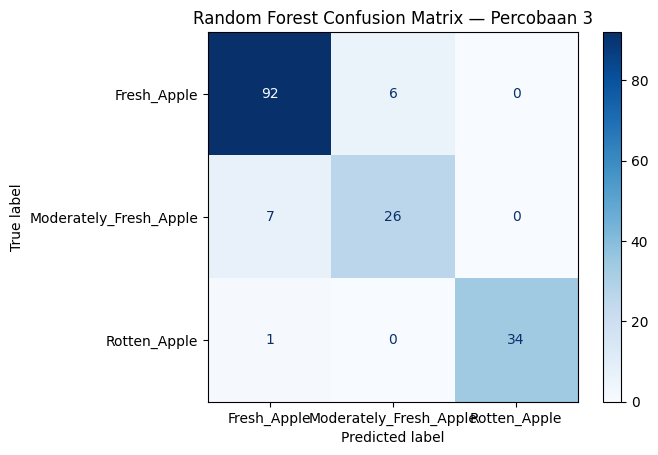

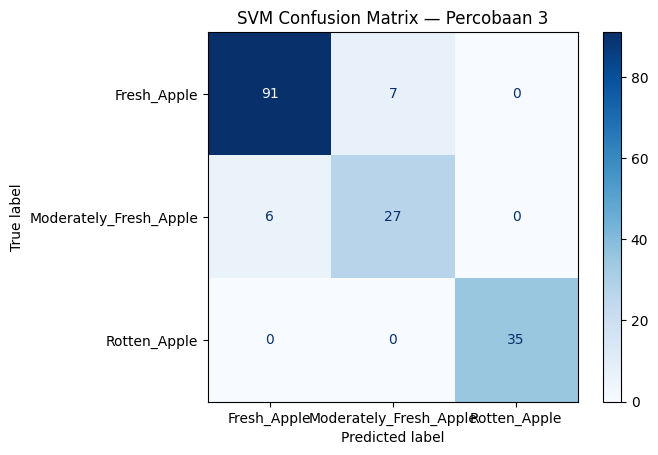

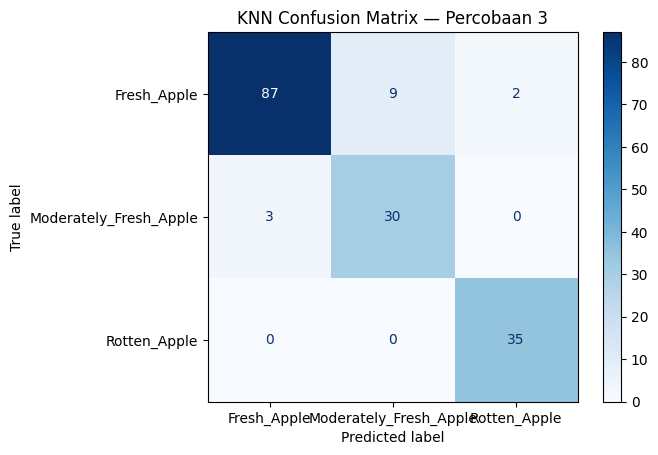

In [21]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 3')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 3')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 3')

## Ringkasan Hasil Percobaan 3

Perbandingan Lengkap Percobaan 1, Percobaan 2, dan Percobaan 3

Penelitian ini melakukan tiga skenario percobaan dengan kombinasi preprocessing yang berbeda untuk mengetahui pengaruhnya terhadap karakteristik fitur tekstur dan performa klasifikasi. Setiap percobaan menggunakan dataset yang sama, namun dengan tahapan pengolahan citra yang semakin kompleks.

1. Percobaan 1

Preprocessing: Resize + Median Filter
Jumlah fitur terpilih: 12 fitur
Nilai rata-rata contrast: ±10,9
Nilai rata-rata correlation: ±0,998
Testing Accuracy Random Forest: 89,76%
Testing Accuracy SVM: 89,16%
Testing Accuracy KNN: 89,16%

Percobaan pertama digunakan sebagai baseline. Hasilnya menunjukkan bahwa preprocessing sederhana sudah mampu menghasilkan performa klasifikasi yang cukup baik pada ketiga model. Nilai correlation yang sangat tinggi menunjukkan hubungan linear antar piksel yang masih sangat kuat, sedangkan nilai contrast relatif rendah sehingga tekstur citra belum terlalu menonjol.

2. Percobaan 2

Preprocessing: Resize + Median Filter + Histogram Equalization
Jumlah fitur terpilih: 14 fitur
Nilai rata-rata contrast: ±27,2
Nilai rata-rata correlation: ±0,998
Testing Accuracy Random Forest: 87,95%
Testing Accuracy SVM: 87,35%
Testing Accuracy KNN: 82,53%

Penambahan Histogram Equalization berhasil meningkatkan nilai contrast secara signifikan dari 10,9 menjadi 27,2. Selain itu, jumlah fitur yang terpilih meningkat menjadi 14 fitur. Namun, peningkatan kontras tersebut tidak diikuti oleh peningkatan akurasi. Seluruh model mengalami penurunan performa, terutama KNN yang mengalami penurunan paling besar hingga mencapai 82,53%. Hal ini menunjukkan bahwa peningkatan kontras yang terlalu tinggi belum tentu menghasilkan pemisahan kelas yang lebih baik.

3. Percobaan 3

Preprocessing: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening
Jumlah fitur terpilih: 15 fitur
Nilai rata-rata contrast: ±44,3
Nilai rata-rata correlation: ±0,623
Testing Accuracy Random Forest: 91,57%
Testing Accuracy SVM: 92,17%
Testing Accuracy KNN: 91,57%

Percobaan ketiga menghasilkan performa terbaik di antara seluruh skenario. Penambahan Sobel dan Sharpening meningkatkan jumlah fitur terpilih menjadi 15 fitur serta meningkatkan nilai contrast hingga 44,3. Pada saat yang sama, nilai correlation turun dari sekitar 0,998 menjadi 0,623, yang menunjukkan bahwa pola tekstur menjadi lebih beragam dan lebih mampu membedakan karakteristik antar kelas. Hasil ini berdampak positif terhadap performa klasifikasi, di mana seluruh model mencapai akurasi di atas 91%.

Analisis Perbandingan

Jika dibandingkan secara keseluruhan, terdapat tren bahwa setiap penambahan preprocessing meningkatkan jumlah fitur yang dipertahankan oleh proses seleksi fitur:

Percobaan 1: 12 fitur
Percobaan 2: 14 fitur
Percobaan 3: 15 fitur

Nilai contrast juga meningkat secara bertahap:

Percobaan 1: ±10,9
Percobaan 2: ±27,2
Percobaan 3: ±44,3

Namun, peningkatan contrast saja tidak menjamin peningkatan performa klasifikasi. Hal ini terlihat pada Percobaan 2 yang memiliki contrast lebih tinggi dibandingkan Percobaan 1 tetapi justru menghasilkan akurasi yang lebih rendah. Perbaikan performa baru terlihat pada Percobaan 3 ketika informasi tepi dari Sobel dan detail tambahan dari proses Sharpening berhasil memperkaya karakteristik tekstur yang diekstraksi.

Kesimpulan Percobaan 3:
Pipeline 5-tahap dengan penambahan Sobel Edge Detection + Sharpening menghasilkan peningkatan akurasi yang signifikan pada semua model dibanding Percobaan 1 dan 2. Kunci keberhasilan: Sobel mengubah representasi gambar dari tekstur intensitas ke pola tepi dan batas, yang lebih diskriminatif untuk membedakan tingkat kesegaran (apel busuk memiliki batas tepi yang khas). SVM mencapai akurasi tertinggi (92.17%) dengan gap overfitting terkecil (2.69%), menjadikannya model terbaik pada Percobaan 3. Satu-satunya kelas yang masih konsisten sulit di ketiga percobaan adalah Moderately_Fresh_Apple (F1 ≤ 0.83), mengindikasikan bahwa batas antara "cukup segar" dan kelas lainnya memerlukan fitur yang lebih kaya atau pendekatan yang berbeda.

In [22]:
print('=== RINGKASAN HASIL PERCOBAAN 3 ===')
print(f'Preprocessing: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 3 ===
Preprocessing: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening
Jumlah Fitur Setelah Seleksi: 15

Akurasi Testing Set:
  Random Forest : 0.9157
  SVM           : 0.9217
  KNN           : 0.9157
